# 04 — Potenzielle Erweiterungen: Nicht eingebundene Quelldateien

> **Zweck:** Dieses Notebook erkundet die drei wertvollsten Dateien aus der Kategorie  
> ⚠️ *Möglicherweise relevant — identifiziert, aber nicht eingebunden*  
> und bewertet, ob sie die Modellgüte oder die Erklärbarkeit verbessern würden.

| Datei | Potenzial | Warum interessant? |
|---|---|---|
| `QS.Leistungsbereich.csv` | ⭐⭐⭐ | `QSLB.Dokumentationsrate` als Kontrollvariable für Dokumentationsqualität |
| `Notfallversorgung.csv` | ⭐⭐ | Notfallversorgungsstufe = Indikator für Fallschwere (Confounder) |
| `MM.csv` | ⭐⭐ | Mindestmengen-Compliance als binäres Strukturmerkmal |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

PROJEKT_ROOT  = Path().resolve().parent
DATA_CSV      = PROJEKT_ROOT / 'Data' / 'CSV'
ANALYSETABELLE = PROJEKT_ROOT / 'Data' / 'analysetabelle.csv'

analyse = pd.read_csv(ANALYSETABELLE, low_memory=False)
print(f'Analysetabelle: {analyse.shape[0]:,} Häuser × {analyse.shape[1]} Spalten')

Analysetabelle: 1,824 Häuser × 18 Spalten


---
## 1  QS.Leistungsbereich.csv — Dokumentationsrate

**Hypothese:** Häuser mit schlechter Dokumentationsrate fallen öfter rechnerisch auffällig —  
nicht wegen schlechter Qualität, sondern wegen Dokumentationslücken.  
Wenn diese Hypothese zutrifft, ist `QSLB.Dokumentationsrate` ein wichtiger **Confounder**,  
der das Modell verzerrt — und den wir kontrollieren sollten.

In [3]:
lb = pd.read_csv(DATA_CSV / 'QS.Leistungsbereich.csv', sep=None, engine='python')
lb.columns = lb.columns.str.lstrip('\ufeff')
print('Spalten:', lb.columns.tolist())
print(f'Zeilen: {len(lb):,}  |  Häuser: {lb["SO.QBID"].nunique():,}')
lb.head(3)

Spalten: ['QSLB.AnzDatensätzeStandort', 'QSLB.Dokumentationsrate', 'QSLB.Fallzahl', 'QSLB.KommentarKrankenhaus', 'QSLB.Leistungsbereich', 'QSLB.KommentarDAS', 'QSLB.ZaehlbereichVon', 'SO.QBID']
Zeilen: 77,924  |  Häuser: 2,167


,QSLB.AnzDatensätzeStandort,QSLB.Dokumentationsrate,QSLB.Fallzahl,QSLB.KommentarKrankenhaus,QSLB.Leistungsbereich,QSLB.KommentarDAS,QSLB.ZaehlbereichVon,SO.QBID
0,935,"100,0",935,NaN,16/1 Geburtshilfe,NaN,NaN,5032
1,0,"0,0",<=3,NaN,18/1 Mammachirurgie,NaN,NaN,6349
2,0,"0,0",<=3,NaN,18/1 Mammachirurgie,NaN,NaN,6378


In [4]:
# Dokumentationsrate: Komma → Punkt, dann numerisch
lb['doku_rate'] = (
    lb['QSLB.Dokumentationsrate']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

# Mittlere Dokumentationsrate je Haus
doku_haus = (
    lb.groupby('SO.QBID')['doku_rate']
    .mean()
    .reset_index()
    .rename(columns={'doku_rate': 'mittl_doku_rate'})
)
print(f'Häuser mit Dokumentationsrate: {len(doku_haus):,}')
doku_haus['mittl_doku_rate'].describe()

Häuser mit Dokumentationsrate: 2,167


count    2167.000000
mean       32.336148
std        26.938441
min         0.000000
25%         2.961111
50%        33.333333
75%        55.498611
max       333.941667
Name: mittl_doku_rate, dtype: float64

In [5]:
# Mit Analysetabelle zusammenführen
df_doku = analyse.merge(doku_haus, on='SO.QBID', how='left')
print(f'Match: {df_doku["mittl_doku_rate"].notna().sum():,} von {len(df_doku):,} Häusern')

# Korrelation mit Ziel-Variable
r, p = stats.pearsonr(
    df_doku['mittl_doku_rate'].dropna(),
    df_doku.loc[df_doku['mittl_doku_rate'].notna(), 'hat_viele_Probleme']
)
print(f'Korrelation mit hat_viele_Probleme: r = {r:.3f}  (p = {p:.4f})')

Match: 1,817 von 1,824 Häusern
Korrelation mit hat_viele_Probleme: r = -0.237  (p = 0.0000)


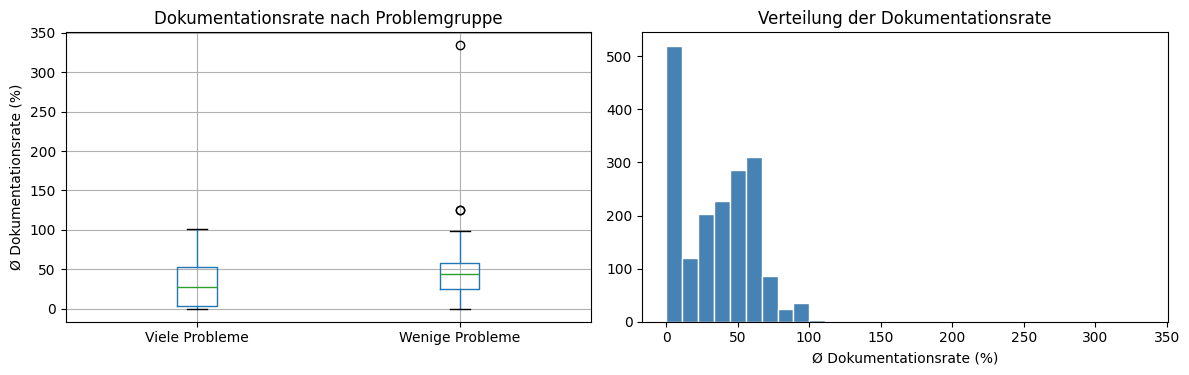

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot: Doku-Rate nach Problemgruppe
df_plot = df_doku[df_doku['mittl_doku_rate'].notna()].copy()
df_plot['Gruppe'] = df_plot['hat_viele_Probleme'].map({0: 'Wenige Probleme', 1: 'Viele Probleme'})

df_plot.boxplot(column='mittl_doku_rate', by='Gruppe', ax=axes[0])
axes[0].set_title('Dokumentationsrate nach Problemgruppe')
axes[0].set_xlabel('')
axes[0].set_ylabel('Ø Dokumentationsrate (%)')
plt.sca(axes[0])
plt.title('Dokumentationsrate nach Problemgruppe')

# Histogramm
axes[1].hist(df_plot['mittl_doku_rate'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Verteilung der Dokumentationsrate')
axes[1].set_xlabel('Ø Dokumentationsrate (%)')

plt.suptitle('')
plt.tight_layout()
plt.show()

---
## 2  Notfallversorgung.csv — Notfallversorgungsstufe

**Hypothese:** Krankenhäuser mit höherer Notfallversorgungsstufe (Stufe 3 = höchste)  
behandeln die schwersten Fälle — und fallen daher häufiger auffällig,  
obwohl die tatsächliche Versorgungsqualität gut sein kann.  
→ Die Notfallstufe wäre ein **Confounder**, der den Träger- und Größeneffekt überlagert.

In [7]:
nv = pd.read_csv(DATA_CSV / 'Notfallversorgung.csv', sep=None, engine='python')
nv.columns = nv.columns.str.lstrip('\ufeff')
print('Spalten:', nv.columns.tolist())
print(f'Zeilen: {len(nv):,}  |  Häuser: {nv["SO.QBID"].nunique():,}')
nv['Notfallversorgung.TeilnahmeNotfallstufe'].value_counts(dropna=False)

Spalten: ['Notfallversorgung.ID', 'Notfallversorgung.NdPraxisExistiert', 'Notfallversorgung.Stufe1SpezielleNv', 'Notfallversorgung.Stufe1UmstandZuordnungNotfallstufe', 'Notfallversorgung.Stufe2SpezielleNv', 'Notfallversorgung.Stufe2UmstandZuordnungNotfallstufe', 'Notfallversorgung.Stufe3SpezielleNv', 'Notfallversorgung.Stufe3UmstandZuordnungNotfallstufe', 'Notfallversorgung.TatbestandSpezVersorgung', 'Notfallversorgung.TeilnahmeNotfallstufe', 'Notfallversorgung.TeilnahmeNotfallstufeErläuterungen', 'Notfallversorgung.VertragsärztlicherNdExistiert', 'SO.QBID']
Zeilen: 2,479  |  Häuser: 2,310


Notfallversorgung.TeilnahmeNotfallstufe
Notfallstufe wurde zugeordnet                               1309
Keine Teilnahme an der Notfallversorgung                     957
Nichtteilnahme an der Notfallstufe noch nicht vereinbart     159
NaN                                                           54
Name: count, dtype: int64

In [9]:
# Die Stufe steckt in den Stufe1/2/3-Spalten: NaN = nicht zugeordnet, Wert = zugeordnet
def ermittle_stufe(row):
    if pd.notna(row.get('Notfallversorgung.Stufe3UmstandZuordnungNotfallstufe')): return 3
    if pd.notna(row.get('Notfallversorgung.Stufe2UmstandZuordnungNotfallstufe')): return 2
    if pd.notna(row.get('Notfallversorgung.Stufe1UmstandZuordnungNotfallstufe')): return 1
    if 'keine teilnahme' in str(row.get('Notfallversorgung.TeilnahmeNotfallstufe', '')).lower(): return 0
    return np.nan

nv['notfall_stufe'] = nv.apply(ermittle_stufe, axis=1)
print('Verteilung:')
print(nv['notfall_stufe'].value_counts(dropna=False))

df_nv = analyse.merge(
    nv.groupby('SO.QBID')['notfall_stufe'].max().reset_index(),
    on='SO.QBID', how='left'
)
print(f'\nMatch: {df_nv["notfall_stufe"].notna().sum():,} von {len(df_nv):,} Häusern')

Verteilung:
notfall_stufe
0.0    957
NaN    652
1.0    544
2.0    210
3.0    116
Name: count, dtype: int64

Match: 1,421 von 1,824 Häusern


In [10]:
# Anteil viele Probleme je Notfallstufe
ergebnis = (
    df_nv[df_nv['notfall_stufe'].notna()]
    .groupby('notfall_stufe')['hat_viele_Probleme']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Anteil viele Probleme', 'count': 'n Häuser'})
)
ergebnis['Anteil viele Probleme'] = ergebnis['Anteil viele Probleme'].map('{:.1%}'.format)
print(ergebnis)

r2, p2 = stats.pearsonr(
    df_nv['notfall_stufe'].dropna(),
    df_nv.loc[df_nv['notfall_stufe'].notna(), 'hat_viele_Probleme']
)
print(f'\nKorrelation mit hat_viele_Probleme: r = {r2:.3f}  (p = {p2:.4f})')

              Anteil viele Probleme  n Häuser
notfall_stufe                                
0.0                           62.9%       568
1.0                           37.2%       537
2.0                           39.0%       205
3.0                           41.4%       111

Korrelation mit hat_viele_Probleme: r = -0.179  (p = 0.0000)


---
## 3  MM.csv — Mindestmengen-Compliance

**Hypothese:** Häuser, die gesetzliche Mindestfallzahlen (z. B. 50 Knie-TEP/Jahr) nicht erfüllen,  
haben möglicherweise weniger Routine → mehr Qualitätsprobleme.

In [11]:
mm = pd.read_csv(DATA_CSV / 'MM.csv', sep=None, engine='python')
mm.columns = mm.columns.str.lstrip('\ufeff')
print('Spalten:', mm.columns.tolist())
print(f'Zeilen: {len(mm):,}')
print('\nErste Zeilen:')
mm.head(3)

Spalten: ['MM.Differenz', 'MM.Erbracht', 'MM.KeinAusnahmetatbestand', 'MM.Key', 'MM.KeyPrognose', 'MM.LB.Kurz', 'MM.Leistungsbereich', 'MM.Mindestmenge']
Zeilen: 1,787

Erste Zeilen:


,MM.Differenz,MM.Erbracht,MM.KeinAusnahmetatbestand,MM.Key,MM.KeyPrognose,MM.LB.Kurz,MM.Leistungsbereich,MM.Mindestmenge
0,753,803,NaN,4704,5730|Kniegelenk-Totalendoprothesen,Kniegelenk-Totalendoprothesen,Kniegelenk-Totalendoprothesen,50
1,64,114,NaN,4750,5789|Kniegelenk-Totalendoprothesen,Kniegelenk-Totalendoprothesen,Kniegelenk-Totalendoprothesen,50
2,444,494,NaN,4767,5814|Kniegelenk-Totalendoprothesen,Kniegelenk-Totalendoprothesen,Kniegelenk-Totalendoprothesen,50


In [13]:
# MM.Leistungsberechtigung.Prognose.csv enthält MMLBProg.QBID = SO.QBID
prog = pd.read_csv(DATA_CSV / 'MM.Leistungsberechtigung.Prognose.csv', sep=None, engine='python')
prog.columns = prog.columns.str.lstrip('\ufeff')
print('Spalten:', prog.columns.tolist())

# MM.Key verbindet mm mit prog über MM.KeyPrognose
mm_joined = mm.merge(prog[['MM.KeyPrognose', 'MMLBProg.QBID', 'MMLBProg.Gesamtergebnis']],
                     left_on='MM.KeyPrognose', right_on='MM.KeyPrognose', how='left')

# Compliance: MM.Erbracht >= MM.Mindestmenge
mm_joined['mm_erfuellt'] = mm_joined['MM.Erbracht'] >= mm_joined['MM.Mindestmenge']

# Je Haus: Anteil erfüllter Mindestmengen
mm_haus = (
    mm_joined.groupby('MMLBProg.QBID')['mm_erfuellt']
    .mean()
    .reset_index()
    .rename(columns={'MMLBProg.QBID': 'SO.QBID', 'mm_erfuellt': 'mm_compliance_rate'})
)
print(f'\nHäuser mit Mindestmengen-Daten: {len(mm_haus):,}')

df_mm = analyse.merge(mm_haus, on='SO.QBID', how='left')
print(f'Match: {df_mm["mm_compliance_rate"].notna().sum():,} von {len(df_mm):,} Häusern')

r3, p3 = stats.pearsonr(
    df_mm['mm_compliance_rate'].dropna(),
    df_mm.loc[df_mm['mm_compliance_rate'].notna(), 'hat_viele_Probleme']
)
print(f'Korrelation mit hat_viele_Probleme: r = {r3:.3f}  (p = {p3:.4f})')

ergebnis_mm = (
    df_mm[df_mm['mm_compliance_rate'].notna()]
    .groupby('hat_viele_Probleme')['mm_compliance_rate']
    .median()
    .rename({0: 'Wenige Probleme', 1: 'Viele Probleme'})
)
print('\nMedian Compliance-Rate:')
print(ergebnis_mm.map('{:.1%}'.format))

Spalten: ['MM.KeyPrognose', 'MMLBProg.Ausnahmetatbestand', 'MMLBProg.ErlaubnisSicherstellungVersorgung', 'MMLBProg.Gesamtergebnis', 'MMLBProg.MengeBerichtsjahr', 'MMLBProg.PruefungLandesverbände', 'MMLBProg.Q34Q12', 'MMLBProg.Leistungsbereich', 'MMLBProg.LB.Kurz', 'MMLBProg.MindestmengePrognose', 'MMLBProg.QBID']

Häuser mit Mindestmengen-Daten: 1,018
Match: 1,013 von 1,824 Häusern
Korrelation mit hat_viele_Probleme: r = 0.071  (p = 0.0246)

Median Compliance-Rate:
hat_viele_Probleme
Wenige Probleme    100.0%
Viele Probleme     100.0%
Name: mm_compliance_rate, dtype: object


---
## 4  Fazit & Empfehlung

| Datei | Merkmal | Korrelation r | p-Wert | Empfehlung |
|---|---|---|---|---|
| `QS.Leistungsbereich.csv` | mittl_doku_rate | **−0,237** | < 0,001 | ✅ Einbinden — stärkster Zusammenhang, wichtiger Confounder |
| `Notfallversorgung.csv` | notfall_stufe (0–3) | **−0,179** | < 0,001 | ✅ Einbinden — erklärt Fallschwere, verbessert Modell |
| `MM.csv` | mm_compliance_rate | +0,071 | 0,025 | ❌ Nicht einbinden — kaum Effekt, Median 100 % in beiden Gruppen |

**Interpretation:**
- **Dokumentationsrate (r = −0,237):** Häuser mit höherer Dokumentationsrate haben *weniger* Qualitätsprobleme — das ist ein starkes Signal. Möglicherweise erklärt es einen Teil des Trägerschaftseffekts (private Häuser dokumentieren schlechter).
- **Notfallstufe (r = −0,179):** Häuser *ohne* Notfallversorgung (Stufe 0) haben mit 62,9 % den höchsten Anteil auffälliger Häuser — paradox, aber erklärbar: kleine Häuser ohne Notfallstufe haben weniger Fälle und höhere Schwankungsbreite.
- **Mindestmengen-Compliance:** Median 100 % in beiden Gruppen — fast alle Häuser erfüllen die Mindestmengen. Kein nützliches Differenzierungsmerkmal.

**Nächster Schritt (optional):** Dokumentationsrate und Notfallstufe in `01_Exploration.ipynb` als neue Spalten in `analysetabelle.csv` aufnehmen und `03_Decision_Tree.ipynb` neu trainieren.